Partie 1


Nombre de points sur la grille= 100
Étape= 1    ;   Err= 0.14960284078964947
Étape= 2    ;   Err= 0.050379497814918725
Étape= 3    ;   Err= 0.001494488983272436
Étape= 4    ;   Err= 1.443242149925121e-06
Étape= 5    ;   Err= 1.411497930663841e-12
Étape= 6    ;   Err= 5.9213048644162e-14
q= 100000 Tmax= 509.2231359535726


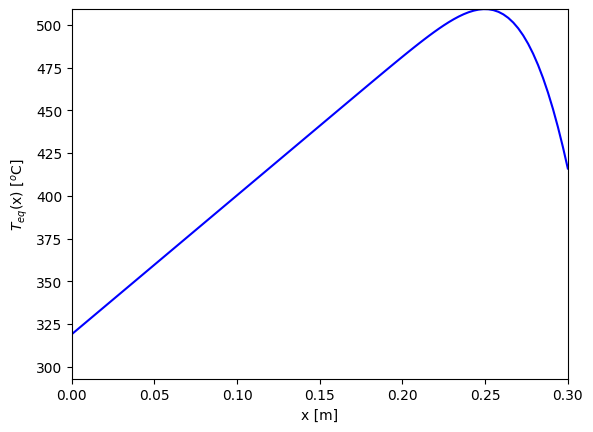

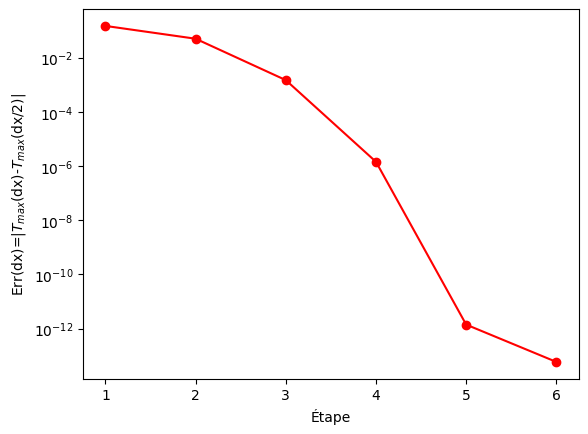

La température maximale est 509.223 K, la température à x=0 est 319.064 K et la température à x = L est 415.983 K


In [100]:
import numpy as np
import matplotlib.pyplot as plt

# Équation différentielle: d^2 u/dx^2=g(x) sur x=(a,b)

# Équation de transfert de chaleur d^2 T/dx^2=-S(x)/k sur x=(0,L)
# dans un mur d'isolation thermique
L=0.3; #[m] ; Épaisseur du mur

k=0.85; #[W/(m*K)]; La conductivité thermique de la brique
si=5.67e-8; #constante de Stefan-Boltzmann
h=20
To=293; #oK

# Condition radiative à x=0 (face externe du mur): 

c1=-k; c2=h; c3=-si*To**4-h*To;
# Condition radiative à x=L (face interne du mur):
d1=-k; d2=-h; d3=si*To**4+h*To;


N=100;
print('Nombre de points sur la grille=', N)
dx = L/N;  # Pas de discrétisation
x = np.linspace(0, L, N+1);
T = To*np.ones(N+1, dtype=np.double);# Pour commencer les itérations

S=np.zeros(N+1,dtype=np.double);
A = np.zeros((N+1, N+1), dtype=np.double);
J = np.zeros((N+1, N+1), dtype=np.double);
b = np.zeros(N+1, dtype=np.double);
dT = np.zeros(N+1, dtype=np.double);
F = np.zeros(N+1, dtype=np.double);

# Sourse volumique de chaleur q[W/m^3] d'épaisseur dL
# La source est intégrée dans la partie intérieure du mur
dL = 0.05;
q = 10**5;  # W/m^3
S = q*np.exp(-((x-L)/dL)**2);

Err=[];

# matrice pleine
A=np.diag(-2*np.ones(N+1),0)+np.diag(np.ones(N),-1)+np.diag(np.ones(N),1); 
A[0,0]=2*c2*dx-3*c1;A[0,1]=4*c1;A[0,2]=-c1
A[N,N]=3*d1+2*d2*dx;A[N,N-1]=-4*d1;A[N,N-2]=d1

ci=-1;flag=1;tol=1e-12;

while flag:    
    ci = ci+1;

    b=S/k*dx**2; b[0]=T[0]**4*2*dx*si+2*c3*dx; b[N]=2*dx*d3-2*dx*si*T[N]**4;
    
    F=A@T+b;

    Err.append(sum(np.abs(F))/(N+1));
    print('Étape=', ci+1, '   ;   Err=', Err[ci])
    if (Err[ci]<tol):
        flag=0;
        
    J=A.copy();J[0,0]=A[0,0]+T[0]**3*8*dx*si;J[N,N]=A[N,N]-T[N]**3*8*dx*si
    dT=-np.linalg.solve(J,F);
    T=T+dT;

    
plt.plot(x,T,'b')
Tmax=T.max();
print('q=',q,'Tmax=',Tmax)    

plt.axis([x[0], x[-1], To, Tmax])

plt.xlabel('x [m]')    
plt.ylabel('$T_{eq}$(x) [$^o$C]')
plt.show()

plt.figure(2)
plt.plot(np.arange(1, ci + 2),Err,'-or');
plt.yscale('log')
plt.xlabel('Étape')
plt.ylabel('Err(dx)=|$T_{max}$(dx)-$T_{max}$(dx/2)|')
plt.show()

print(f'La température maximale est {T.max():.3f} K, la température à x=0 est {T[0]:.3f} K et la température à x = L est {T[-1]:.3f} K')


Partie 2

In [93]:
#Pour simplifier l'écriture, definnissons une fonction pour trouver Tmax avec la méthode de Newton
def TrouveTmax(qessai) :
  
    L=0.3; #[m] ; Épaisseur du mur

    k=0.85; #[W/(m*K)]; La conductivité thermique de la brique
    si=5.67e-8; #constante de Stefan-Boltzmann
    h=20
    To=293; #oK

    c1=-k; c2=h; c3=-si*To**4-h*To;
    d1=-k; d2=-h; d3=si*To**4+h*To;


    N=100;

    dx = L/N;  # Pas de discrétisation
    x = np.linspace(0, L, N+1);
    T = To*np.ones(N+1, dtype=np.double);# Pour commencer les itérations

    S=np.zeros(N+1,dtype=np.double);
    A = np.zeros((N+1, N+1), dtype=np.double);
    J = np.zeros((N+1, N+1), dtype=np.double);
    b = np.zeros(N+1, dtype=np.double);
    dT = np.zeros(N+1, dtype=np.double);
    F = np.zeros(N+1, dtype=np.double);


    dL = 0.05;
    q = qessai;  # W/m^3
    S = q*np.exp(-((x-L)/dL)**2);

    Err=[];

# matrice pleine
    A=np.diag(-2*np.ones(N+1),0)+np.diag(np.ones(N),-1)+np.diag(np.ones(N),1); 
    A[0,0]=2*c2*dx-3*c1;A[0,1]=4*c1;A[0,2]=-c1
    A[N,N]=3*d1+2*d2*dx;A[N,N-1]=-4*d1;A[N,N-2]=d1

    ci=-1;flag=1;tol=1e-12;

    while flag:    
        ci = ci+1;

        b=S/k*dx**2; b[0]=T[0]**4*2*dx*si+2*c3*dx; b[N]=2*dx*d3-2*dx*si*T[N]**4;
    
        F=A@T+b;

        Err.append(sum(np.abs(F))/(N+1));
        
        if (Err[ci]<tol):
            flag=0;
        
        J=A.copy();J[0,0]=A[0,0]+T[0]**3*8*dx*si;J[N,N]=A[N,N]-T[N]**3*8*dx*si
        dT=-np.linalg.solve(J,F);
        T=T+dT;


    Tmax=T.max();
    return Tmax

In [94]:
qGauche, qDroit = 1e5, 1e7
qb_err = []
seuil=2250

while abs(qDroit-qGauche)/qDroit > 1e-12:
    qessai = 0.5*(qGauche+qDroit)
    
    Tmax=TrouveTmax(qessai)

    qb_err.append(abs(qDroit-qGauche)/qDroit)

    if Tmax > seuil:
        qDroit = qessai
    else:
        qGauche = qessai

q_max = 0.5*(qGauche+qDroit)


La valeur q trouvée est 1284608.248
Pour cette valeur, la température maximale est 2250.000


Text(0.5, 0, 'Étape')

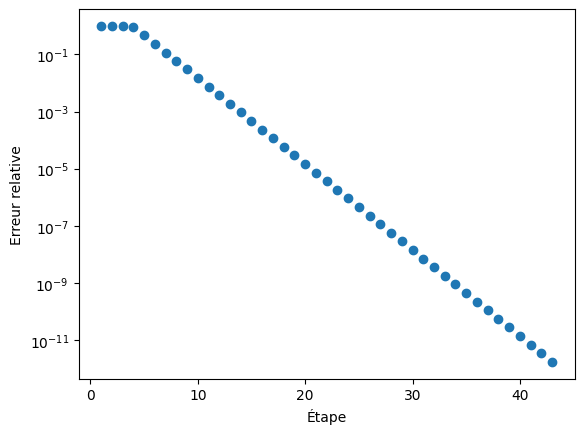

In [97]:
print(f'La valeur q trouvée est {q_max:.3f}')
print(f'Pour cette valeur, la température maximale est {TrouveTmax(q_max):.3f}')
xerr = np.arange(1, len(qb_err)+1)
plt.scatter(xerr,qb_err)
plt.yscale('log')
plt.ylabel('Erreur relative')
plt.xlabel('Étape')

Étape= 1    ;   Err= 1.921810431530907
Étape= 2    ;   Err= 70.06223576839116
Étape= 3    ;   Err= 21.543450054222692
Étape= 4    ;   Err= 6.191080870431662
Étape= 5    ;   Err= 1.4270880596771083
Étape= 6    ;   Err= 0.16753249213223093
Étape= 7    ;   Err= 0.0033637648015571804
Étape= 8    ;   Err= 1.440728021092091e-06
Étape= 9    ;   Err= 4.895470125214982e-13
q= 1284608.2476689673 Tmax= 2250.000000000268


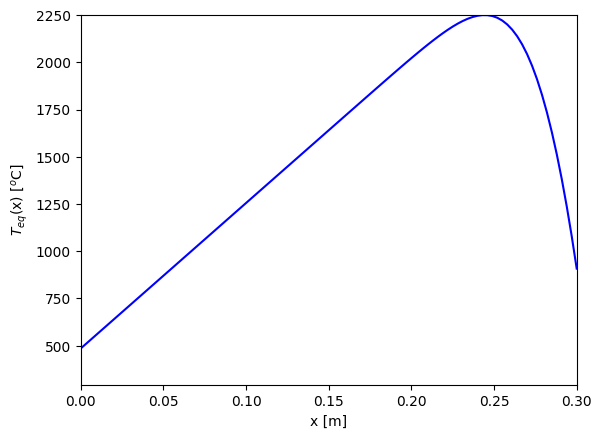

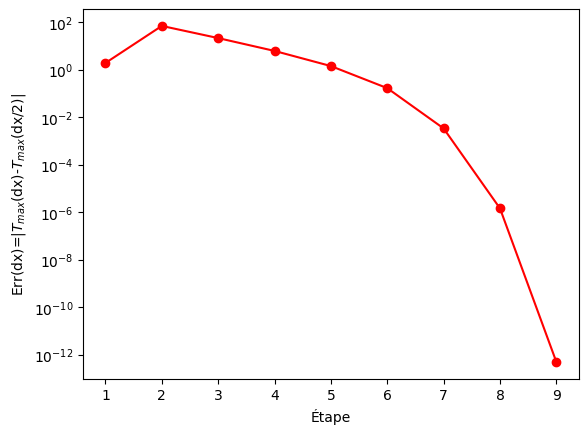

La température maximale est 2250.000 K, la température à x=0 est 484.746 K et la température à x = L est 907.708 K


In [ ]:

T = To*np.ones(N+1, dtype=np.double); #essai initial

S=np.zeros(N+1,dtype=np.double); #constantes
A = np.zeros((N+1, N+1), dtype=np.double);
J = np.zeros((N+1, N+1), dtype=np.double);
b = np.zeros(N+1, dtype=np.double);
dT = np.zeros(N+1, dtype=np.double);
F = np.zeros(N+1, dtype=np.double);
dL = 0.05;
q = q_max;  # W/m^3
S = q*np.exp(-((x-L)/dL)**2);

Err=[];

# matrice pleine
A=np.diag(-2*np.ones(N+1),0)+np.diag(np.ones(N),-1)+np.diag(np.ones(N),1); 
A[0,0]=2*c2*dx-3*c1;A[0,1]=4*c1;A[0,2]=-c1
A[N,N]=3*d1+2*d2*dx;A[N,N-1]=-4*d1;A[N,N-2]=d1

ci=-1;flag=1;tol=1e-12;

while flag:    
    ci = ci+1;

    b=S/k*dx**2; b[0]=T[0]**4*2*dx*si+2*c3*dx; b[N]=2*dx*d3-2*dx*si*T[N]**4;
    
    F=A@T+b;

    Err.append(sum(np.abs(F))/(N+1));
    print('Étape=', ci+1, '   ;   Err=', Err[ci])
    if (Err[ci]<tol):
        flag=0;
        
    J=A.copy();J[0,0]=A[0,0]+T[0]**3*8*dx*si;J[N,N]=A[N,N]-T[N]**3*8*dx*si
    dT=-np.linalg.solve(J,F);
    T=T+dT;

    
plt.plot(x,T,'b')
Tmax=T.max();
print('q=',q,'Tmax=',Tmax)    

plt.axis([x[0], x[-1], To, Tmax])

plt.xlabel('x [m]')    
plt.ylabel('$T_{eq}$(x) [$^o$C]')
plt.show()

plt.figure(2)
plt.plot(np.arange(1, ci + 2),Err,'-or');
plt.yscale('log')
plt.xlabel('Étape')
plt.ylabel('Err(dx)=|$T_{max}$(dx)-$T_{max}$(dx/2)|')
plt.show()

print(f'La température maximale est {T.max():.3f} K, la température à x=0 est {T[0]:.3f} K et la température à x = L est {T[-1]:.3f} K')
